In [ ]:
# Block 1: Install Dependencies
!pip install -q ultralytics opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.7 MB/s eta 0:00:00


In [ ]:
# Block 1: Imports & Nutrition Database Setup
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files

# JSON Database with per-gram nutritional values
NUTRITION_DB = {
    "foods": [
        {
            "id": "bhat",
            "name": "Cooked Rice",
            "veg_or_nonveg": "veg",
            "nutrition_per_gram": {
                "calories": 1.30,
                "protein": 0.027,
                "carbohydrates": 0.282,
                "fat": 0.003
            }
        },
        {
            "id": "dal",
            "name": "Dal",
            "veg_or_nonveg": "veg",
            "nutrition_per_gram": {
                "calories": 1.16,
                "protein": 0.090,
                "carbohydrates": 0.201,
                "fat": 0.004
            }
        },
        {
            "id": "sabji",
            "name": "Vegetable Sabji",
            "veg_or_nonveg": "veg",
            "nutrition_per_gram": {
                "calories": 0.75,
                "protein": 0.020,
                "carbohydrates": 0.100,
                "fat": 0.030
            }
        }
    ]
}

# Convert DB list into a fast lookup dictionary
FOOD_LOOKUP = {food["id"]: food for food in NUTRITION_DB["foods"]}

# Grams-Per-Pixel (GPP) mapping to convert mask pixel area to estimated weight
GRAMS_PER_PIXEL = {
    "bhat": 0.0035,
    "dal": 0.0020,
    "sabji": 0.0028,
    "default": 0.0025
}

In [ ]:
# Block 2: Load YOLO Segmentation Model
MODEL_PATH = "/content/runs/segment/nepali_plate_final_run/weights/best.pt"

if os.path.exists(MODEL_PATH):
    model = YOLO(MODEL_PATH)
    print(f"Loaded YOLO Segmentation Model from {MODEL_PATH}")
else:
    print(f"Model path '{MODEL_PATH}' not found. Please upload 'best.pt':")
    uploaded = files.upload()
    MODEL_PATH = list(uploaded.keys())[0]
    model = YOLO(MODEL_PATH)

Model path '/content/runs/segment/nepali_plate_final_run/weights/best.pt' not found. Please upload 'best.pt':


Saving best.pt to best (3).pt


Upload an image of a Nepali plate to test:


Saving test 7.jpg to test 7.jpg

image 1/1 /content/test 7.jpg: 640x480 1 bhat, 1 dal, 1 sabji, 213.3ms
Speed: 3.1ms preprocess, 213.3ms inference, 9.4ms postprocess per image at shape (1, 3, 640, 480)

================ TEST 1 ================
INPUT IMAGE: 'test 7.jpg'

IDENTIFIED FOOD ITEMS (Conf >= 50%):
  - [bhat] Cooked Rice: 180.6g (234.8 kcal, 4.88g P, 50.93g C, 0.54g F)
  - [sabji] Vegetable Sabji: 72.5g (54.4 kcal, 1.45g P, 7.25g C, 2.18g F)
  - [dal] Dal: 54.0g (62.7 kcal, 4.86g P, 10.86g C, 0.22g F)

TOTAL NUTRITION: {'calories': 351.8, 'protein': 11.19, 'carbs': 69.04, 'fat': 2.93}


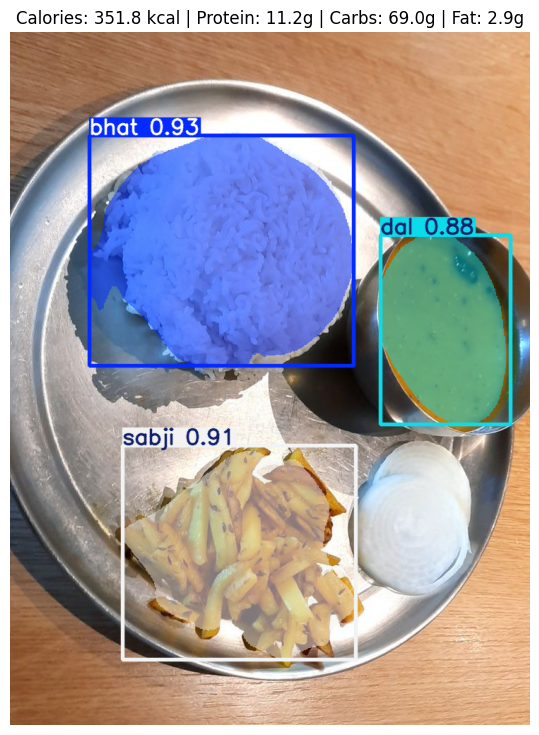

In [ ]:
# Block 3: Robust Scale Calibration & Weight Calculation
print("Upload an image of a Nepali plate to test:")
uploaded_img = files.upload()
IMAGE_PATH = list(uploaded_img.keys())[0]

# Run YOLO model inference (Conf >= 50%)
results = model(IMAGE_PATH, conf=0.50)[0]

# --- PHYSICAL CONSTANTS ---
KNOWN_PLATE_DIAMETER_CM = 27.0  # Standard Nepali thali diameter

# Measured densities & heights for realistic single plate portions
PHYSICAL_PROFILES = {
    "bhat": {"name": "Cooked Rice", "height_cm": 2.0, "density_g_cm3": 0.82},
    "dal": {"name": "Dal", "height_cm": 1.2, "density_g_cm3": 1.01},
    "sabji": {"name": "Vegetable Sabji", "height_cm": 1.4, "density_g_cm3": 0.70},
    "default": {"name": "Nepali Dish", "height_cm": 1.5, "density_g_cm3": 0.75}
}

totals = {"calories": 0.0, "protein": 0.0, "carbs": 0.0, "fat": 0.0}

print("\n================ TEST 1 ================")
print(f"INPUT IMAGE: '{IMAGE_PATH}'\n")
print("IDENTIFIED FOOD ITEMS (Conf >= 50%):")

if results.masks is not None:
    masks = results.masks.data.cpu().numpy()
    boxes = results.boxes

    # Get bounding coordinates of ALL detected items on the plate combined
    all_x1 = boxes.xyxy[:, 0].cpu().numpy()
    all_x2 = boxes.xyxy[:, 2].cpu().numpy()

    # Measure total pixel span across all detected items
    combined_items_pixel_span = max(all_x2) - min(all_x1)

    # A full Nepali thali layout usually spans ~85% of the combined detection width
    # This prevents side bowls from breaking the calculation
    estimated_plate_px_width = combined_items_pixel_span * 0.85

    # Pixels per centimeter scaling
    px_per_cm = estimated_plate_px_width / KNOWN_PLATE_DIAMETER_CM
    sq_px_per_sq_cm = px_per_cm ** 2

    valid_detections_found = False

    for i, mask in enumerate(masks):
        conf = float(boxes.conf[i])
        if conf < 0.50:
            continue

        valid_detections_found = True
        cls_id = int(boxes.cls[i])
        cls_name = model.names[cls_id].lower()

        # 1. Surface Area: Pixels -> cm²
        pixel_count = np.sum(mask > 0.5)
        surface_area_sq_cm = pixel_count / sq_px_per_sq_cm

        # 2. Volume (cm³) & Weight (g)
        profile = PHYSICAL_PROFILES.get(cls_name, PHYSICAL_PROFILES["default"])
        volume_cm3 = surface_area_sq_cm * profile["height_cm"]
        weight_g = volume_cm3 * profile["density_g_cm3"]

        # 3. Nutrition calculation
        food_info = FOOD_LOOKUP.get(cls_name, FOOD_LOOKUP["sabji"])
        nutr = food_info["nutrition_per_gram"]

        item_cal = weight_g * nutr["calories"]
        item_p = weight_g * nutr["protein"]
        item_c = weight_g * nutr["carbohydrates"]
        item_f = weight_g * nutr["fat"]

        # Totals
        totals["calories"] += item_cal
        totals["protein"] += item_p
        totals["carbs"] += item_c
        totals["fat"] += item_f

        print(f"  - [{cls_name}] {food_info['name']}: {weight_g:.1f}g "
              f"({item_cal:.1f} kcal, {item_p:.2f}g P, {item_c:.2f}g C, {item_f:.2f}g F)")

    if valid_detections_found:
        formatted_totals = {
            'calories': float(round(totals["calories"], 1)),
            'protein': float(round(totals["protein"], 2)),
            'carbs': float(round(totals["carbs"], 2)),
            'fat': float(round(totals["fat"], 2))
        }
        print(f"\nTOTAL NUTRITION: {formatted_totals}")
    else:
        print("No food items met the minimum 50% confidence threshold.")
else:
    print("No food items segmented in the given image.")


# Block 4: Plot Output
annotated_img = cv2.cvtColor(results.plot(conf=True), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(9, 9))
plt.imshow(annotated_img)
plt.axis("off")
plt.title(f"Calories: {totals['calories']:.1f} kcal | Protein: {totals['protein']:.1f}g | Carbs: {totals['carbs']:.1f}g | Fat: {totals['fat']:.1f}g")
plt.show()

In [ ]:
# Block 4: Visualize Annotated Segmentation Overlay
annotated_img = cv2.cvtColor(results.plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(9, 9))
plt.imshow(annotated_img)
plt.axis("off")
plt.title(f"Calories: {totals['calories']:.1f} kcal | Protein: {totals['protein']:.1f}g | Carbs: {totals['carbs']:.1f}g | Fat: {totals['fat']:.1f}g")
plt.show()